# [ Computer Vision ] [ CSE445 ] [ Assignment-2 ]

**Dataset Name:** IoTKITs<br>
**Source Link:** https://data.mendeley.com/datasets/x5thzmkxhy/1

## Configuration

In [1]:
!pip install ultralytics timm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 632.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.8 MB/s eta 0:00:00


In [2]:
import os
import math
import time
import random
import random as pyrandom
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# partition splits
partition_dir  = "/kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition"
ssl_pool_dir   = os.path.join(partition_dir, "ssl_pool_images")
val_images_dir = os.path.join(partition_dir, "yolo_rho20", "images", "val")
val_labels_dir = os.path.join(partition_dir, "yolo_rho20", "labels", "val")
print("Partition dataset contents:", sorted(os.listdir(partition_dir)), "\n")

working_dir = "/kaggle/working/"
os.makedirs(working_dir, exist_ok=True)

METHOD    = "I-JEPA"
FAMILY    = "Masked Latent Prediction"
ENCODER   = "ViT (from scratch) + YOLOv12s CNN distillation"
BEST_YAML = "yolo12s.yaml"

MASK_CFG = {
    "num_target_blocks":   4,
    "target_scale":        (0.15, 0.20),
    "target_aspect_ratio": (0.75, 1.5),
    "context_scale":       (0.85, 1.0),
}

SEED         = 42
IMGSZ_SSL    = 224
PATCH_SIZE   = 16
EMBED_DIM    = 384
DEPTH        = 12
NUM_HEADS    = 6
BATCH        = 64
EPOCHS       = 200
LR           = 1e-3
WEIGHT_DECAY = 0.04
WARMUP_FRAC  = 0.10
EMA_START    = 0.996
EMA_END      = 1.0
AMP          = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GRID_SIZE = IMGSZ_SSL // PATCH_SIZE

print("\n====== Configuration ======\n")
print("Method           :", METHOD)
print("Encoder          :", ENCODER)
print("Distill target   :", BEST_YAML)
print("Device           :", device)
print("Seed             :", SEED)
print("Image size       :", IMGSZ_SSL)
print("Patch size       :", PATCH_SIZE)
print("Grid size        :", GRID_SIZE, "x", GRID_SIZE)
print("Embed dim        :", EMBED_DIM)
print("Depth / heads    :", DEPTH, "/", NUM_HEADS)
print("Batch size       :", BATCH)
print("Epochs           :", EPOCHS)
print("LR               :", LR)
print("Weight decay     :", WEIGHT_DECAY)
print("Warmup fraction  :", WARMUP_FRAC)
print("EMA momentum     :", EMA_START, "->", EMA_END)
print("Mixed precision  :", "ON (AMP)" if AMP else "OFF")
print("\nMasking policy:")
for k, v in MASK_CFG.items():
    print(f"{k:22s}: {v}")

Partition dataset contents: ['__notebook__.ipynb', '__output__.json', '__results__.html', 'custom.css', 'splits', 'ssl_pool_images', 'yolo_rho20'] 


====== Configuration ======

Method           : I-JEPA
Encoder          : ViT (from scratch) + YOLOv12s CNN distillation
Distill target   : yolo12s.yaml
Device           : cuda
Seed             : 42
Image size       : 224
Patch size       : 16
Grid size        : 14 x 14
Embed dim        : 384
Depth / heads    : 12 / 6
Batch size       : 64
Epochs           : 200
LR               : 0.001
Weight decay     : 0.04
Warmup fraction  : 0.1
EMA momentum     : 0.996 -> 1.0
Mixed precision  : ON (AMP)

Masking policy:
num_target_blocks     : 4
target_scale          : (0.15, 0.2)
target_aspect_ratio   : (0.75, 1.5)
context_scale         : (0.85, 1.0)


## Subset Verification

In [3]:
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

def stem_set(folder):
    names = set()
    for f in os.listdir(folder):
        if not f.lower().endswith(IMG_EXT):
            continue
        stem = f.split("__", 1)[1] if "__" in f else f
        names.add(os.path.splitext(stem)[0])
    return names

ssl_names  = stem_set(ssl_pool_dir)
val_names  = stem_set(val_images_dir)
total = len(ssl_names) + len(val_names)

print("Partition sizes (seed =", SEED, "):")
print(f"SSL pool     : {len(ssl_names):5d}  ({len(ssl_names)/total:6.2%})")
print(f"Validation   : {len(val_names):5d}  ({len(val_names)/total:6.2%})")
print(f"TOTAL |D|    : {total:5d}")

print("\nDisjointness Check:")
i_vs = val_names & ssl_names
print(f"val ∩ ssl_pool : {len(i_vs)}  -> {'PASS' if not i_vs else 'FAIL'}")
assert not i_vs, "LEAKAGE"

Partition sizes (seed = 42 ):
SSL pool     :  2485  (88.88%)
Validation   :   311  (11.12%)
TOTAL |D|    :  2796

Disjointness Check:
val ∩ ssl_pool : 0  -> PASS


## Model - ViT Encoder, Predictor, EMA Target + Loss

In [4]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size, patch_size, embed_dim):
        super().__init__()
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.proj = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        return x.flatten(2).transpose(1, 2)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(embed_dim, hidden), nn.GELU(), nn.Linear(hidden, embed_dim))

    def forward(self, x):
        h = self.norm1(x)
        attn_out, _ = self.attn(h, h, h, need_weights=False)
        x = x + attn_out
        return x + self.mlp(self.norm2(x))


class ViTEncoder(nn.Module):
    def __init__(self, img_size, patch_size, embed_dim, depth, num_heads):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, embed_dim)
        num_patches = self.patch_embed.num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x, patch_indices=None):
        tokens = self.patch_embed(x) + self.pos_embed
        if patch_indices is not None:
            idx = torch.tensor(sorted(patch_indices), device=x.device)
            tokens = tokens[:, idx, :]
        for block in self.blocks:
            tokens = block(tokens)
        return self.norm(tokens)


class Predictor(nn.Module):
    def __init__(self, embed_dim, predictor_embed_dim, depth, num_heads, num_patches):
        super().__init__()
        self.embed_in = nn.Linear(embed_dim, predictor_embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, predictor_embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.blocks = nn.ModuleList([TransformerBlock(predictor_embed_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(predictor_embed_dim)
        self.embed_out = nn.Linear(predictor_embed_dim, embed_dim)

    def forward(self, context_tokens, target_patch_indices):
        x = self.embed_in(context_tokens)
        idx = torch.tensor(sorted(target_patch_indices), device=context_tokens.device)
        target_pos = self.pos_embed[:, idx, :].expand(x.size(0), -1, -1)
        x = torch.cat([x, target_pos], dim=1)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        num_target = target_pos.size(1)
        return self.embed_out(x[:, -num_target:, :])


context_encoder = ViTEncoder(IMGSZ_SSL, PATCH_SIZE, EMBED_DIM, DEPTH, NUM_HEADS).to(device)
target_encoder  = ViTEncoder(IMGSZ_SSL, PATCH_SIZE, EMBED_DIM, DEPTH, NUM_HEADS).to(device)
predictor = Predictor(EMBED_DIM, predictor_embed_dim=192, depth=6,
                       num_heads=NUM_HEADS, num_patches=GRID_SIZE * GRID_SIZE).to(device)

target_encoder.load_state_dict(context_encoder.state_dict())
for p in target_encoder.parameters():
    p.requires_grad = False

def update_ema(context_encoder, target_encoder, momentum):
    with torch.no_grad():
        for p_ctx, p_tgt in zip(context_encoder.parameters(), target_encoder.parameters()):
            p_tgt.data.mul_(momentum).add_(p_ctx.data, alpha=(1 - momentum))

def get_momentum(step, total_steps, m_start, m_end):
    return m_start + (m_end - m_start) * (step / max(total_steps, 1))

def ijepa_loss(predictions, target_full, target_blocks_list):
    losses = []
    for b in range(predictions.size(0)):
        pred_b, offset = predictions[b], 0
        for patch_idx in target_blocks_list[b]:
            n = len(patch_idx)
            losses.append(F.smooth_l1_loss(pred_b[offset:offset + n], target_full[b, patch_idx, :].detach()))
            offset += n
    return torch.stack(losses).mean()

n_params = lambda m: sum(p.numel() for p in m.parameters())
print("Context encoder params:", n_params(context_encoder))
print("Target encoder params :", n_params(target_encoder))
print("Predictor params      :", n_params(predictor))

dummy_pred = torch.randn(2, 20, EMBED_DIM).to(device)
dummy_target_full = torch.randn(2, GRID_SIZE * GRID_SIZE, EMBED_DIM).to(device)
dummy_blocks = [[list(range(10)), list(range(10, 20))], [list(range(15)), list(range(15, 20))]]
print("Sanity-check loss (random tensors, should be ~0.1-1.0):", ijepa_loss(dummy_pred, dummy_target_full, dummy_blocks).item())

Context encoder params: 21664896
Target encoder params : 21664896
Predictor params      : 2855232
Sanity-check loss (random tensors, should be ~0.1-1.0): 0.7349814772605896


## Masking Policy + Dataset

In [5]:
def sample_block_patches(grid_size, scale_range, aspect_ratio_range, rng):
    max_area = grid_size * grid_size
    for _ in range(10):
        target_area = rng.uniform(*scale_range) * max_area
        aspect_ratio = rng.uniform(*aspect_ratio_range)
        h = min(int(round(math.sqrt(target_area * aspect_ratio))), grid_size)
        w = min(int(round(math.sqrt(target_area / aspect_ratio))), grid_size)
        if h < 1 or w < 1:
            continue
        row_start = rng.randint(0, grid_size - h)
        col_start = rng.randint(0, grid_size - w)
        return (row_start, row_start + h, col_start, col_start + w)
    return (0, grid_size, 0, grid_size)

def block_to_patch_indices(block, grid_size):
    row_start, row_end, col_start, col_end = block
    return {r * grid_size + c for r in range(row_start, row_end) for c in range(col_start, col_end)}

def sample_context_and_targets(grid_size, mask_cfg, rng):
    target_blocks, target_patch_indices = [], set()
    for _ in range(mask_cfg["num_target_blocks"]):
        block = sample_block_patches(grid_size, mask_cfg["target_scale"], mask_cfg["target_aspect_ratio"], rng)
        target_blocks.append(block)
        target_patch_indices |= block_to_patch_indices(block, grid_size)
    context_block = sample_block_patches(grid_size, mask_cfg["context_scale"], (1.0, 1.0), rng)
    context_patch_indices = block_to_patch_indices(context_block, grid_size) - target_patch_indices
    return context_patch_indices, target_blocks, target_patch_indices

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

base_transform = T.Compose([
    T.Resize((IMGSZ_SSL, IMGSZ_SSL)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class IJEPADataset(Dataset):
    def __init__(self, image_dir, mask_cfg, transform):
        self.image_dir = image_dir
        self.files = sorted(os.listdir(image_dir))
        self.mask_cfg = mask_cfg
        self.transform = transform
        self.grid_size = IMGSZ_SSL // PATCH_SIZE

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.image_dir, self.files[idx])).convert("RGB")
        img_tensor = self.transform(img)
        rng = pyrandom.Random(SEED + idx)
        ctx_patches, tgt_blocks, _ = sample_context_and_targets(self.grid_size, self.mask_cfg, rng)
        tgt_patch_lists = [sorted(block_to_patch_indices(b, self.grid_size)) for b in tgt_blocks]
        return {"image": img_tensor, "context_patches": sorted(ctx_patches), "target_patch_lists": tgt_patch_lists}

def ijepa_collate(batch):
    return {
        "images": torch.stack([item["image"] for item in batch]),
        "context_patches_list": [item["context_patches"] for item in batch],
        "target_patch_lists_list": [item["target_patch_lists"] for item in batch],
    }

from PIL import Image

ssl_dataset = IJEPADataset(ssl_pool_dir, MASK_CFG, base_transform)
ssl_loader = DataLoader(ssl_dataset, batch_size=BATCH, shuffle=True, collate_fn=ijepa_collate, num_workers=2, drop_last=True)

print("SSL pool images:", len(ssl_dataset))
print("Batches per epoch:", len(ssl_loader))

SSL pool images: 2485
Batches per epoch: 38


## Sanity Check - Context/Target Masking Demo (Single Image)

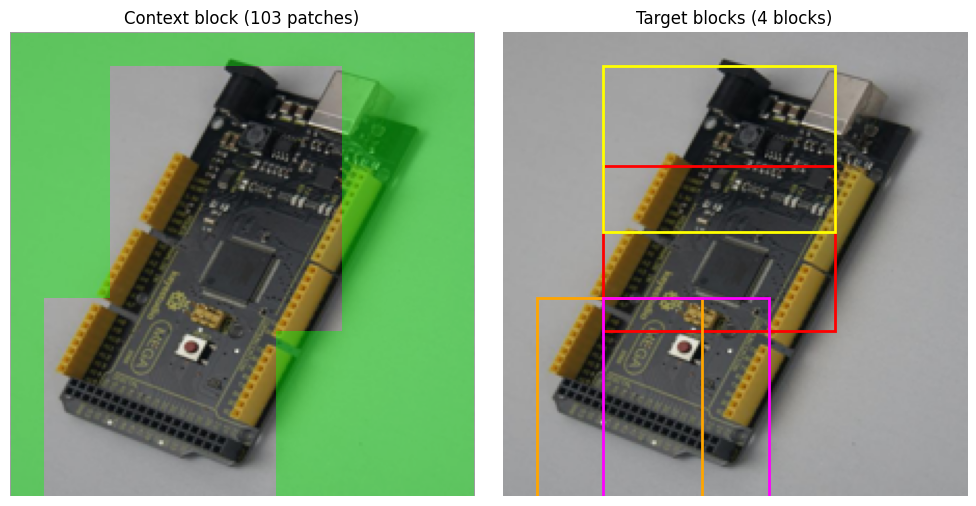

Sample image: train_1000__CEAC1_jpg.rf.c0c38c7fdcd0ed55abfb04600aa99ee7.jpg


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

rng = pyrandom.Random(SEED)
ctx_patches, tgt_blocks, tgt_patches = sample_context_and_targets(GRID_SIZE, MASK_CFG, rng)

sample_path = os.path.join(ssl_pool_dir, sorted(os.listdir(ssl_pool_dir))[0])
img = Image.open(sample_path).convert("RGB").resize((IMGSZ_SSL, IMGSZ_SSL))
patch_px = PATCH_SIZE

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title(f"Context block ({len(ctx_patches)} patches)")
for idx in ctx_patches:
    r, c = divmod(idx, GRID_SIZE)
    axes[0].add_patch(mpatches.Rectangle((c * patch_px, r * patch_px), patch_px, patch_px,
                                          linewidth=0, facecolor="lime", alpha=0.4))
axes[0].axis("off")

colors = ["red", "orange", "yellow", "magenta"]
axes[1].imshow(img)
axes[1].set_title(f"Target blocks ({len(tgt_blocks)} blocks)")
for i, block in enumerate(tgt_blocks):
    row_start, row_end, col_start, col_end = block
    axes[1].add_patch(mpatches.Rectangle((col_start * patch_px, row_start * patch_px),
                       (col_end - col_start) * patch_px, (row_end - row_start) * patch_px,
                       linewidth=2, edgecolor=colors[i % len(colors)], facecolor="none"))
axes[1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(working_dir, "ijepa_masking_demo.png"), dpi=150)
plt.show()
print("Sample image:", os.path.basename(sample_path))

## Train I-JEPA (200 Epochs, AMP)

In [7]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

optimizer = AdamW(list(context_encoder.parameters()) + list(predictor.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = EPOCHS * len(ssl_loader)
warmup_steps = int(WARMUP_FRAC * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)
scaler = torch.amp.GradScaler("cuda", enabled=AMP)
epoch_losses = []
global_step = 0

print(f"Training for {EPOCHS} epochs, {len(ssl_loader)} batches/epoch, {total_steps} total steps")
start_time = time.time()

for epoch in range(EPOCHS):
    context_encoder.train(); predictor.train(); target_encoder.eval()
    running_loss = 0.0
    for batch in ssl_loader:
        images = batch["images"].to(device, non_blocking=True)
        context_patches_list = batch["context_patches_list"]
        target_patch_lists_list = batch["target_patch_lists_list"]
        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=AMP):
            with torch.no_grad():
                target_full = target_encoder(images, patch_indices=None)
            batch_preds, batch_targets_flat_idx = [], []
            for b in range(images.size(0)):
                ctx_out = context_encoder(images[b:b+1], patch_indices=context_patches_list[b])
                tgt_lists = target_patch_lists_list[b]
                flat_tgt_idx = [i for block in tgt_lists for i in block]
                batch_preds.append(predictor(ctx_out, flat_tgt_idx).squeeze(0))
                batch_targets_flat_idx.append(tgt_lists)
            max_len = max(p.size(0) for p in batch_preds)
            padded_preds = torch.zeros(images.size(0), max_len, EMBED_DIM, device=device)
            for b, p in enumerate(batch_preds):
                padded_preds[b, :p.size(0)] = p
            loss = ijepa_loss(padded_preds, target_full, batch_targets_flat_idx)

        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update(); scheduler.step()
        momentum = get_momentum(global_step, total_steps, EMA_START, EMA_END)
        update_ema(context_encoder, target_encoder, momentum)
        running_loss += loss.item(); global_step += 1

    avg_loss = running_loss / len(ssl_loader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1:3d}/{EPOCHS}  loss: {avg_loss:.4f}  momentum: {momentum:.5f}  elapsed: {(time.time()-start_time)/60:.1f} min")

print("\nTraining complete.")

Training for 200 epochs, 38 batches/epoch, 7600 total steps
Epoch   1/200  loss: 0.4086  momentum: 0.99602  elapsed: 1.6 min
Epoch   2/200  loss: 0.2826  momentum: 0.99604  elapsed: 3.2 min
Epoch   3/200  loss: 0.2076  momentum: 0.99606  elapsed: 4.8 min
Epoch   4/200  loss: 0.1730  momentum: 0.99608  elapsed: 6.4 min
Epoch   5/200  loss: 0.1575  momentum: 0.99610  elapsed: 7.9 min
Epoch   6/200  loss: 0.1579  momentum: 0.99612  elapsed: 9.5 min
Epoch   7/200  loss: 0.1580  momentum: 0.99614  elapsed: 11.0 min
Epoch   8/200  loss: 0.1617  momentum: 0.99616  elapsed: 12.6 min
Epoch   9/200  loss: 0.1642  momentum: 0.99618  elapsed: 14.2 min
Epoch  10/200  loss: 0.1768  momentum: 0.99620  elapsed: 15.7 min
Epoch  11/200  loss: 0.1806  momentum: 0.99622  elapsed: 17.3 min
Epoch  12/200  loss: 0.1812  momentum: 0.99624  elapsed: 18.8 min
Epoch  13/200  loss: 0.1856  momentum: 0.99626  elapsed: 20.4 min
Epoch  14/200  loss: 0.1876  momentum: 0.99628  elapsed: 22.0 min
Epoch  15/200  loss: 0

## Loss Curve

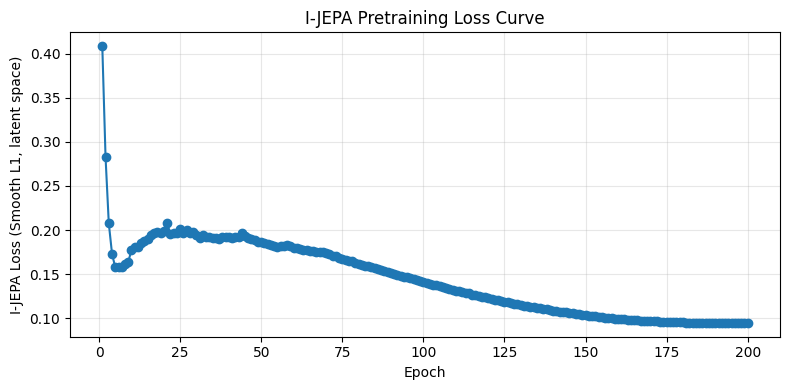

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("I-JEPA Loss (Smooth L1, latent space)")
plt.title("I-JEPA Pretraining Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "ijepa_loss_curve.png"), dpi=150)
plt.show()

## Embedding Visualization: t-SNE + Top-5 Nearest Neighbor Retrieval

Validation embeddings shape: (311, 384)


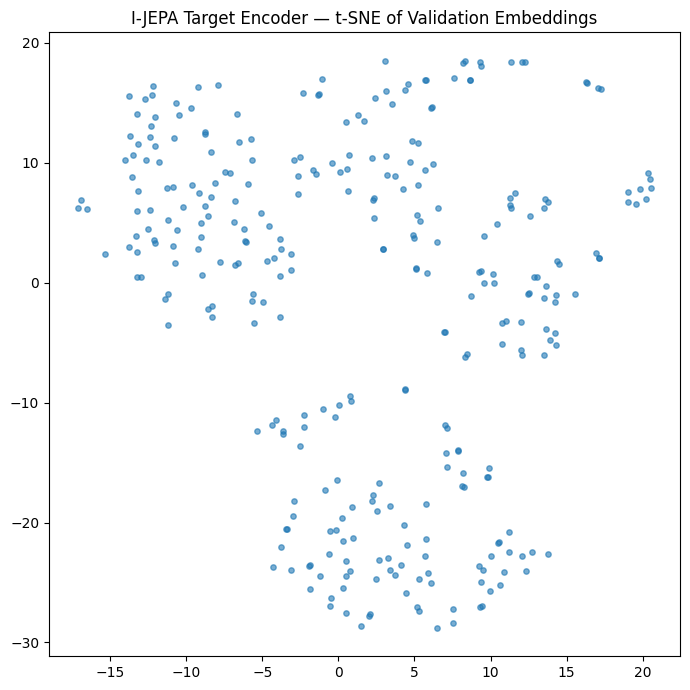

In [9]:
def extract_embedding(encoder, image_tensor):
    encoder.eval()
    with torch.no_grad():
        return encoder(image_tensor.unsqueeze(0).to(device), patch_indices=None).mean(dim=1).squeeze(0).cpu().numpy()

def get_class_from_label_file(label_path):
    if not os.path.exists(label_path):
        return -1
    with open(label_path) as f:
        line = f.readline().strip()
    return int(line.split()[0]) if line else -1

val_files = sorted(os.listdir(val_images_dir))
embeddings, class_ids, filenames = [], [], []
for fname in val_files:
    img = Image.open(os.path.join(val_images_dir, fname)).convert("RGB")
    embeddings.append(extract_embedding(target_encoder, base_transform(img)))
    class_ids.append(get_class_from_label_file(os.path.join(val_labels_dir, os.path.splitext(fname)[0] + ".txt")))
    filenames.append(fname)

embeddings = np.stack(embeddings)
class_ids = np.array(class_ids)
print("Validation embeddings shape:", embeddings.shape)

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(7, 7))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=15, alpha=0.6)
plt.title("I-JEPA Target Encoder — t-SNE of Validation Embeddings")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "ijepa_tsne.png"), dpi=150)
plt.show()

## Top-5 nearest-neighbor

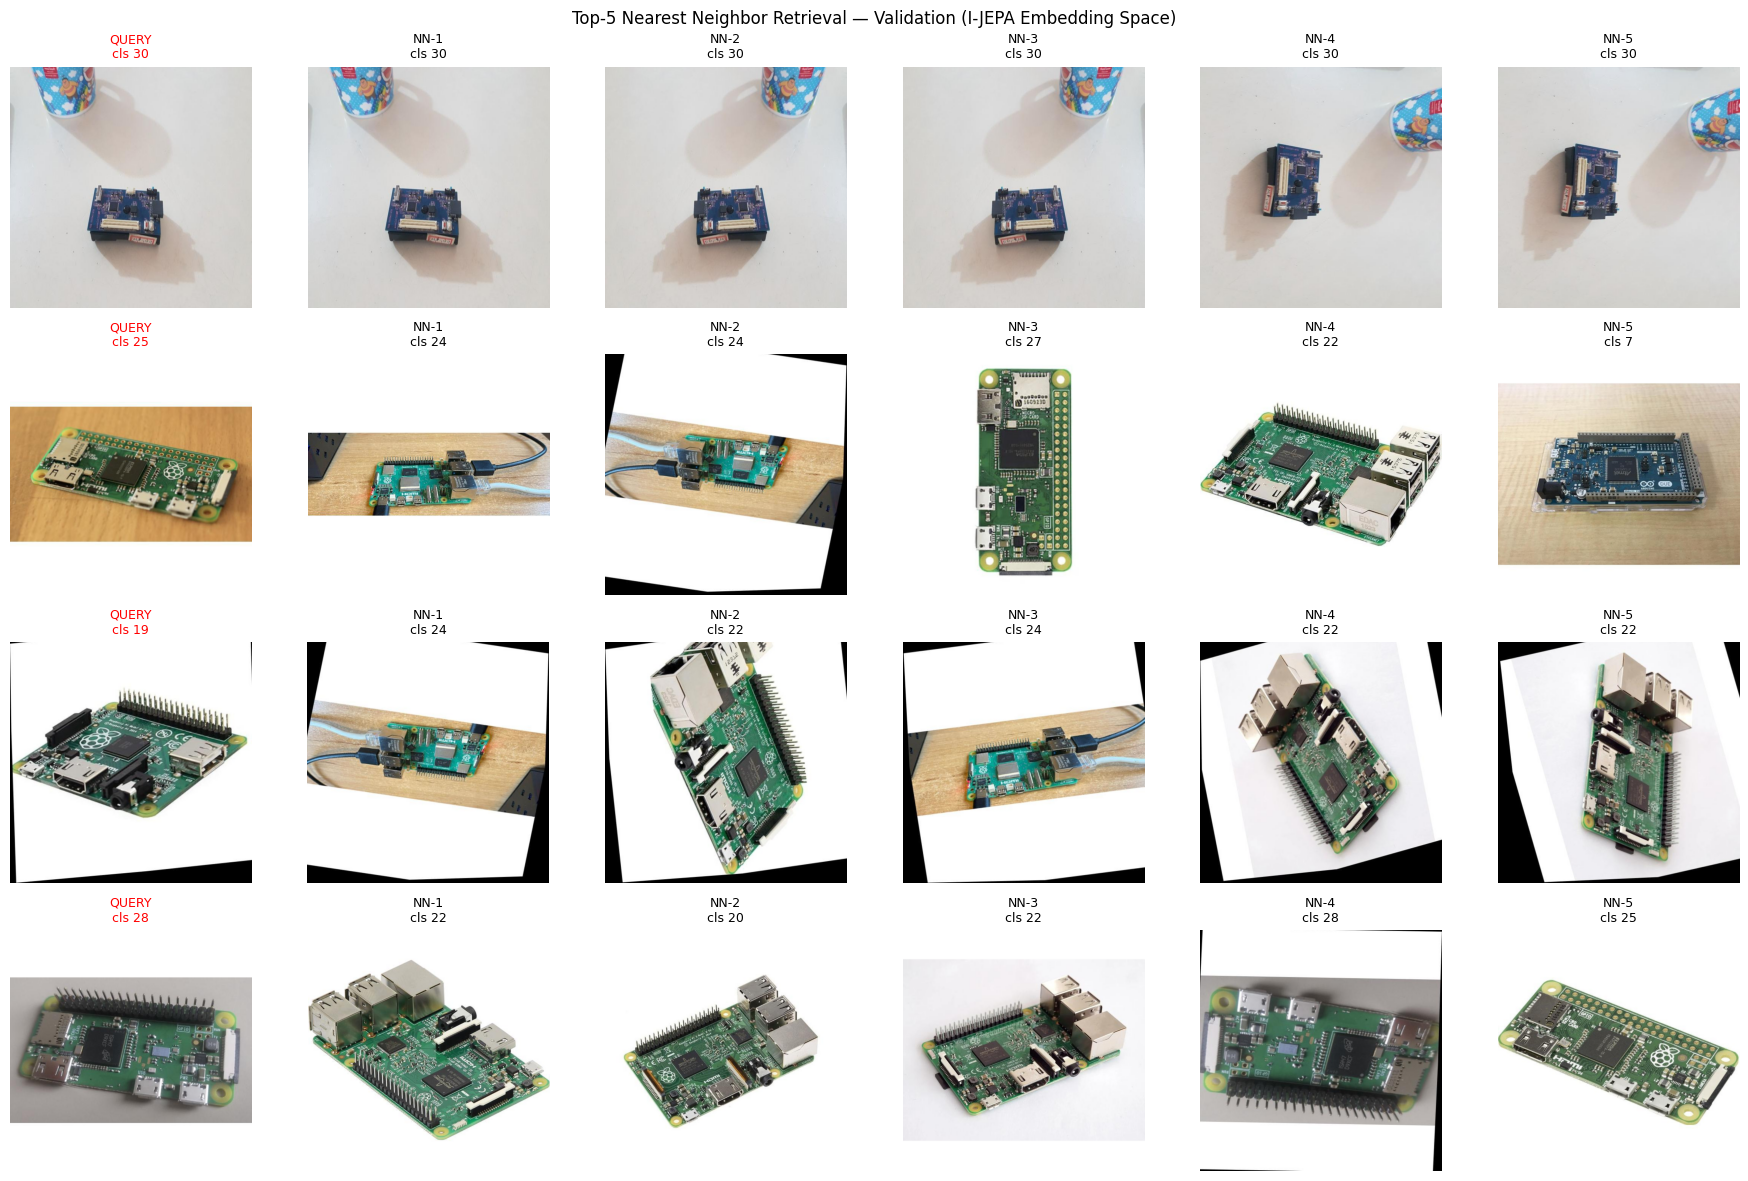

In [10]:
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(n_neighbors=6, metric="cosine")
nn_model.fit(embeddings)
rng_np = np.random.RandomState(SEED)
query_indices = rng_np.choice(len(embeddings), size=4, replace=False)

fig, axes = plt.subplots(len(query_indices), 6, figsize=(18, 3 * len(query_indices)))
for row, q_idx in enumerate(query_indices):
    _, neighbour_idx = nn_model.kneighbors(embeddings[q_idx:q_idx+1])
    for col, n_idx in enumerate(neighbour_idx[0]):
        img = Image.open(os.path.join(val_images_dir, filenames[n_idx])).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        tag = f"QUERY\ncls {class_ids[n_idx]}" if col == 0 else f"NN-{col}\ncls {class_ids[n_idx]}"
        axes[row, col].set_title(tag, fontsize=9, color=("red" if col == 0 else "black"))

plt.suptitle("Top-5 Nearest Neighbor Retrieval — Validation (I-JEPA Embedding Space)")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "ijepa_retrieval_panel.png"), dpi=150)
plt.show()

## CNN Backbone Distillation — ViT Features → YOLOv12s Backbone

In [11]:
from ultralytics import YOLO
import timm

full = YOLO(BEST_YAML).model
n_bb = len(full.yaml["backbone"])
print("backbone layers:", n_bb)

try:
    cnn_backbone = nn.Sequential(*list(full.model[:n_bb])).to(device)
    dummy_out = cnn_backbone(torch.randn(1, 3, IMGSZ_SSL, IMGSZ_SSL).to(device))
    cnn_feat_dim = dummy_out.shape[1]
    print("nn.Sequential backbone worked. Output shape:", dummy_out.shape)
    USE_TIMM = False
except Exception as e:
    print("nn.Sequential backbone FAILED:", e, "\nFalling back to timm encoder (ResNet18)")
    USE_TIMM = True
    cnn_backbone = timm.create_model("resnet18", pretrained=False, num_classes=0, global_pool="").to(device)
    dummy_out = cnn_backbone(torch.randn(1, 3, IMGSZ_SSL, IMGSZ_SSL).to(device))
    cnn_feat_dim = dummy_out.shape[1]

print("Backbone initialised from: fresh (random-init)", BEST_YAML)
print("CNN feature dim:", cnn_feat_dim)

def cnn_forward_pooled(backbone, x):
    return backbone(x).mean(dim=[2, 3])

projector = nn.Sequential(nn.Linear(cnn_feat_dim, 512), nn.ReLU(), nn.Linear(512, EMBED_DIM)).to(device)
print("Projector params:", n_params(projector))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
backbone layers: 9
nn.Sequential backbone worked. Output shape: torch.Size([1, 512, 7, 7])
Backbone initialised from: fresh (random-init) yolo12s.yaml
CNN feature dim: 512
Projector params: 459648


## Distillation Training Loop

In [12]:
DISTILL_EPOCHS = 200

def variance_loss(features, eps=1e-4):
    return torch.mean(F.relu(1.0 - torch.sqrt(features.var(dim=0) + eps)))

def covariance_loss(features):
    B, D = features.shape
    features = features - features.mean(dim=0)
    cov = (features.T @ features) / (B - 1)
    return ((cov - torch.diag(torch.diagonal(cov))) ** 2).sum() / D

target_encoder.eval()
for p in target_encoder.parameters():
    p.requires_grad = False

def cosine_distill_loss(cnn_feat, vit_feat):
    return -(F.normalize(cnn_feat, dim=-1) * F.normalize(vit_feat, dim=-1)).sum(dim=-1).mean()

distill_optimizer = AdamW(list(cnn_backbone.parameters()) + list(projector.parameters()), lr=1e-4, weight_decay=0.05)
distill_total_steps = DISTILL_EPOCHS * len(ssl_loader)
distill_scheduler = LambdaLR(distill_optimizer, lambda step: 0.5 * (1 + math.cos(math.pi * step / max(1, distill_total_steps))))
distill_scaler = torch.amp.GradScaler("cuda", enabled=AMP)

VARIANCE_WEIGHT, COVARIANCE_WEIGHT = 5.0, 1.0
distill_losses = []
print(f"Distilling for {DISTILL_EPOCHS} epochs, {len(ssl_loader)} batches/epoch")
start_time = time.time()

for epoch in range(DISTILL_EPOCHS):
    cnn_backbone.train(); projector.train()
    running_loss = 0.0
    for batch in ssl_loader:
        images = batch["images"].to(device, non_blocking=True)
        distill_optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=AMP):
            with torch.no_grad():
                vit_feat = target_encoder(images, patch_indices=None).mean(dim=1)
            cnn_projected = projector(cnn_forward_pooled(cnn_backbone, images))
            cnn_normed = F.normalize(cnn_projected, dim=-1)
            sim_loss = cosine_distill_loss(cnn_projected, vit_feat)
            var_loss = variance_loss(cnn_normed)
            cov_loss = covariance_loss(cnn_normed)
            loss = sim_loss + VARIANCE_WEIGHT * var_loss + COVARIANCE_WEIGHT * cov_loss
        distill_scaler.scale(loss).backward()
        distill_scaler.step(distill_optimizer); distill_scaler.update(); distill_scheduler.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(ssl_loader)
    distill_losses.append(avg_loss)
    print(f"Distill epoch {epoch+1:3d}/{DISTILL_EPOCHS}  loss: {avg_loss:.4f}  sim: {sim_loss.item():.4f}  "
          f"var: {var_loss.item():.4f}  cov: {cov_loss.item():.4f}  elapsed: {(time.time()-start_time)/60:.1f} min")

print("\nDistillation complete.")

Distilling for 200 epochs, 38 batches/epoch


/tmp/ipykernel_24/123132584.py:45: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  distill_scaler.step(distill_optimizer); distill_scaler.update(); distill_scheduler.step()


Distill epoch   1/200  loss: 4.3991  sim: -0.6213  var: 0.9596  cov: 0.0005  elapsed: 0.2 min
Distill epoch   2/200  loss: 4.1258  sim: -0.7034  var: 0.9576  cov: 0.0004  elapsed: 0.4 min
Distill epoch   3/200  loss: 4.0641  sim: -0.7300  var: 0.9570  cov: 0.0003  elapsed: 0.5 min
Distill epoch   4/200  loss: 4.0279  sim: -0.7606  var: 0.9571  cov: 0.0003  elapsed: 0.7 min
Distill epoch   5/200  loss: 4.0067  sim: -0.7846  var: 0.9567  cov: 0.0003  elapsed: 0.9 min
Distill epoch   6/200  loss: 3.9902  sim: -0.7954  var: 0.9565  cov: 0.0003  elapsed: 1.1 min
Distill epoch   7/200  loss: 3.9774  sim: -0.8051  var: 0.9562  cov: 0.0003  elapsed: 1.3 min
Distill epoch   8/200  loss: 3.9669  sim: -0.8077  var: 0.9559  cov: 0.0002  elapsed: 1.4 min
Distill epoch   9/200  loss: 3.9563  sim: -0.8210  var: 0.9564  cov: 0.0002  elapsed: 1.6 min
Distill epoch  10/200  loss: 3.9454  sim: -0.8412  var: 0.9559  cov: 0.0002  elapsed: 1.8 min
Distill epoch  11/200  loss: 3.9338  sim: -0.8501  var: 0.95

## Distillation Sanity Check — Collapse Verification

In [13]:
cnn_backbone.eval(); projector.eval()
sample_images = next(iter(ssl_loader))["images"][:16].to(device)
with torch.no_grad():
    sample_projected = F.normalize(projector(cnn_forward_pooled(cnn_backbone, sample_images)), dim=-1)
sim_matrix = sample_projected @ sample_projected.T
off_diagonal = sim_matrix[~torch.eye(16, dtype=torch.bool, device=device)]
print("Mean pairwise similarity between DIFFERENT images' CNN features:", off_diagonal.mean().item())

Mean pairwise similarity between DIFFERENT images' CNN features: 0.2103429138660431


## Save Best Checkpoint

In [14]:
ckpt_path = os.path.join(working_dir, "ijepa_backbone.pt")
torch.save(cnn_backbone.state_dict(), ckpt_path)
print("I-JEPA backbone saved:", ckpt_path)

reload_check = nn.Sequential(*list(YOLO(BEST_YAML).model.model[:n_bb]))
missing, unexpected = reload_check.load_state_dict(torch.load(ckpt_path, map_location="cpu"), strict=False)
print("Reload check — missing:", len(missing), "unexpected:", len(unexpected))
print("Reload check passed." if not missing and not unexpected else "Reload check FAILED.")

I-JEPA backbone saved: /kaggle/working/ijepa_backbone.pt
Reload check — missing: 0 unexpected: 0
Reload check passed.
